In [14]:
import os
from pathlib import Path
import joblib
!pip install awscli rasterio segmentation-models-pytorch -q

In [31]:
REPO_DIR  = "/kaggle/working/SAR_Project"
REPO_URL  = "https://github.com/AdityaChaudhary2913/SAR_Project"

if os.path.exists(REPO_DIR):
    print("⏩ Repo exists — pulling latest changes...")
    os.system(f"cd {REPO_DIR} && git pull origin main")
else:
    print("📥 Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

%cd $REPO_DIR
print(f"✅ Repo ready at {REPO_DIR}")

⏩ Repo exists — pulling latest changes...
Updating 6523dcd..b5410a7
Fast-forward
 evaluate.py | 195 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 infer.py    |   0
 train.py    |   2 +-
 3 files changed, 196 insertions(+), 1 deletion(-)
 delete mode 100644 infer.py
/kaggle/working/SAR_Project
✅ Repo ready at /kaggle/working/SAR_Project


From https://github.com/AdityaChaudhary2913/SAR_Project
 * branch            main       -> FETCH_HEAD
   6523dcd..b5410a7  main       -> origin/main


In [3]:
EVENTS = {
    "e7e6e693-aec9-44b2-928d-80ba818b647e": {
        "name": "Spain_Valencia_2019",
        "location": "Valencia & Murcia, southeastern Spain",
        "event": "DANA flash flood (cold drop storm)",
        "date": "September 17, 2019",
        "source": "C2SMSFloods v1 — Cloud to Street + Microsoft, s3://radiant-mlhub/c2smsfloods/",
        "sar_product": "Sentinel-1A IW GRD, VV+VH, 10m resolution",
        "approx_bbox": "Lat 37–39°N, Lon 0–2°W",
    },
    "e92c811f-ba53-4df2-aad0-afea8b733621": {
        "name": "WestAfrica_Niger_2019",
        "location": "Niger / Nigeria border region, West Africa",
        "event": "Niger River seasonal flood",
        "date": "September 9, 2019",
        "source": "C2SMSFloods v1 — Cloud to Street + Microsoft, s3://radiant-mlhub/c2smsfloods/",
        "sar_product": "Sentinel-1A IW GRD, VV+VH, 10m resolution",
        "approx_bbox": "Lat 13–15°N, Lon 1–3°E",
    },
}

In [4]:
# Download Data
for uuid, name in EVENTS.items():
    out_dir = f"data/raw/chips/{uuid}/s1"
    if os.path.exists(out_dir) and len(os.listdir(out_dir)) > 0:
        print(f"⏩ Already exists — skipping {name}")
        continue
    
    os.makedirs(out_dir, exist_ok=True)
    print(f"📥 Downloading {name}...")
    os.system(f"aws s3 cp s3://radiant-mlhub/c2smsfloods/chips/{uuid}/s1/ {out_dir}/ --recursive --no-sign-request")
    print(f"✅ Done: {name}")

⏩ Already exists — skipping {'name': 'Spain_Valencia_2019', 'location': 'Valencia & Murcia, southeastern Spain', 'event': 'DANA flash flood (cold drop storm)', 'date': 'September 17, 2019', 'source': 'C2SMSFloods v1 — Cloud to Street + Microsoft, s3://radiant-mlhub/c2smsfloods/', 'sar_product': 'Sentinel-1A IW GRD, VV+VH, 10m resolution', 'approx_bbox': 'Lat 37–39°N, Lon 0–2°W'}
⏩ Already exists — skipping {'name': 'WestAfrica_Niger_2019', 'location': 'Niger / Nigeria border region, West Africa', 'event': 'Niger River seasonal flood', 'date': 'September 9, 2019', 'source': 'C2SMSFloods v1 — Cloud to Street + Microsoft, s3://radiant-mlhub/c2smsfloods/', 'sar_product': 'Sentinel-1A IW GRD, VV+VH, 10m resolution', 'approx_bbox': 'Lat 13–15°N, Lon 1–3°E'}


In [5]:
# Verify Data
total = 0
for uuid, meta in EVENTS.items():
    base = Path(f"data/raw/chips/{uuid}/s1")
    chip_dirs = [d for d in base.iterdir() if d.is_dir()]
    n = len(chip_dirs)
    total += n

    complete, incomplete = 0, []
    for chip in chip_dirs:
        names = [f.name for f in chip.iterdir()]
        if all(x in names for x in ['VV.tif', 'VH.tif', 'LabelWater.tif']):
            complete += 1
        else:
            incomplete.append(chip.name)

    print(f"\n{'='*55}")
    print(f"📦  {meta['name']}")
    print(f"    Location  : {meta['location']}")
    print(f"    Event     : {meta['event']}")
    print(f"    Date      : {meta['date']}")
    print(f"    SAR       : {meta['sar_product']}")
    print(f"    Bbox      : {meta['approx_bbox']}")
    print(f"    Source    : {meta['source']}")
    print(f"    Chips     : {n} total  |  ✅ {complete} complete  |  ⚠️  {len(incomplete)} incomplete")
    if incomplete:
        print(f"    Missing   : {incomplete[:3]}")

print(f"\n{'='*55}")
print(f"🎯 Total chips across both events: {total}")
print(f"{'='*55}")


📦  Spain_Valencia_2019
    Location  : Valencia & Murcia, southeastern Spain
    Event     : DANA flash flood (cold drop storm)
    Date      : September 17, 2019
    SAR       : Sentinel-1A IW GRD, VV+VH, 10m resolution
    Bbox      : Lat 37–39°N, Lon 0–2°W
    Source    : C2SMSFloods v1 — Cloud to Street + Microsoft, s3://radiant-mlhub/c2smsfloods/
    Chips     : 30 total  |  ✅ 30 complete  |  ⚠️  0 incomplete

📦  WestAfrica_Niger_2019
    Location  : Niger / Nigeria border region, West Africa
    Event     : Niger River seasonal flood
    Date      : September 9, 2019
    SAR       : Sentinel-1A IW GRD, VV+VH, 10m resolution
    Bbox      : Lat 13–15°N, Lon 1–3°E
    Source    : C2SMSFloods v1 — Cloud to Street + Microsoft, s3://radiant-mlhub/c2smsfloods/
    Chips     : 65 total  |  ✅ 65 complete  |  ⚠️  0 incomplete

🎯 Total chips across both events: 95


In [6]:
!python data/preprocess.py

Found 2 event(s) to process

chips: 100%|████████████████████████████████████| 30/30 [00:00<00:00, 39.46it/s]

📦 e7e6e693...
   Total     : 30
   ✅ Saved  : 27
   ⚠️  Nodata : 0
   ⚠️  NoFlood: 3
chips: 100%|████████████████████████████████████| 65/65 [00:00<00:00, 67.21it/s]

📦 e92c811f...
   Total     : 65
   ✅ Saved  : 32
   ⚠️  Nodata : 0
   ⚠️  NoFlood: 33

🎯 Total saved: 59 / 95 chips
   Output at  : data/processed


In [7]:
from data.dataset import get_dataloaders

train_loader, val_loader = get_dataloaders(
    processed_dir="data/processed",
    tile_size=256,
    batch_size=8
)

✅ SARFloodDataset: 236 tiles from 59 chips across 2 events (tile_size=256, augment=False)

📊 Split: 188 train tiles / 48 val tiles
   Train batches: 23  |  Val batches: 6


### For max_samples=200000
IoU=0.6128
F1=0.7599

### For max_samples=200000
IoU=0.6240
F1=0.7685

### For max_samples=500000
IoU=0.6148
F1=0.7615

In [17]:
from models.baseline import train_rf, evaluate_rf

clf = train_rf(train_loader, max_samples=250000)
metrics = evaluate_rf(clf, val_loader)

os.makedirs("/kaggle/working/trained_models", exist_ok=True)
joblib.dump(clf, "/kaggle/working/trained_models/rf_baseline.joblib")

📦 Extracting pixel features from train set...
   Raw   : 12,058,624 pixels, 7.7% flood
   Using : 250,000 pixels (subsampled), 7.7% flood
🌲 Training Random Forest...
✅ Training complete.
💾 Saved to checkpoints/rf_baseline.joblib
📊 Evaluating on val set...

  Baseline RF Results
  IoU : 0.6240
  F1  : 0.7685
  (UNet target IoU: >0.877)


['/kaggle/working/trained_models/rf_baseline.joblib']

In [30]:
from train import main
model, history = main()

🖥️  Device: cuda
✅ SARFloodDataset: 236 tiles from 59 chips across 2 events (tile_size=256, augment=False)

📊 Split: 188 train tiles / 48 val tiles
   Train batches: 23  |  Val batches: 6
✅ UNet ready on cuda
   Parameters : 1,926,721
   Input      : (B, 2, 256, 256)
   Output     : (B, 1, 256, 256) — raw logits

  Starting training — 50 epochs

Epoch 01/50  |  Train Loss: 0.7584  IoU: 0.1724  |  Val Loss: 0.7085  IoU: 0.0001 ⭐
Epoch 02/50  |  Train Loss: 0.6832  IoU: 0.3982  |  Val Loss: 0.5785  IoU: 0.6478 ⭐
Epoch 03/50  |  Train Loss: 0.6520  IoU: 0.5006  |  Val Loss: 0.5069  IoU: 0.7490 ⭐
Epoch 04/50  |  Train Loss: 0.6391  IoU: 0.5473  |  Val Loss: 0.5001  IoU: 0.7809 ⭐
Epoch 05/50  |  Train Loss: 0.6305  IoU: 0.5329  |  Val Loss: 0.4893  IoU: 0.7494
Epoch 06/50  |  Train Loss: 0.6151  IoU: 0.5810  |  Val Loss: 0.4783  IoU: 0.7937 ⭐
Epoch 07/50  |  Train Loss: 0.6013  IoU: 0.5937  |  Val Loss: 0.4679  IoU: 0.8005 ⭐
Epoch 08/50  |  Train Loss: 0.5926  IoU: 0.5864  |  Val Loss: 0.47

✅ SARFloodDataset: 236 tiles from 59 chips across 2 events (tile_size=256, augment=False)

📊 Split: 188 train tiles / 48 val tiles
   Train batches: 23  |  Val batches: 6
✅ UNet ready on cuda
   Parameters : 1,926,721
   Input      : (B, 2, 256, 256)
   Output     : (B, 1, 256, 256) — raw logits
✅ Loaded checkpoint from epoch 12 (Val IoU: 0.8098)

  UNet Evaluation Results
  Val IoU (mean) : 0.4567
  Val IoU (best) : 0.9996
  Val IoU (worst): 0.0000
  Val F1  (mean) : 0.5323
  RF Baseline IoU: 0.6148
  UNet Gain      : +-0.1581



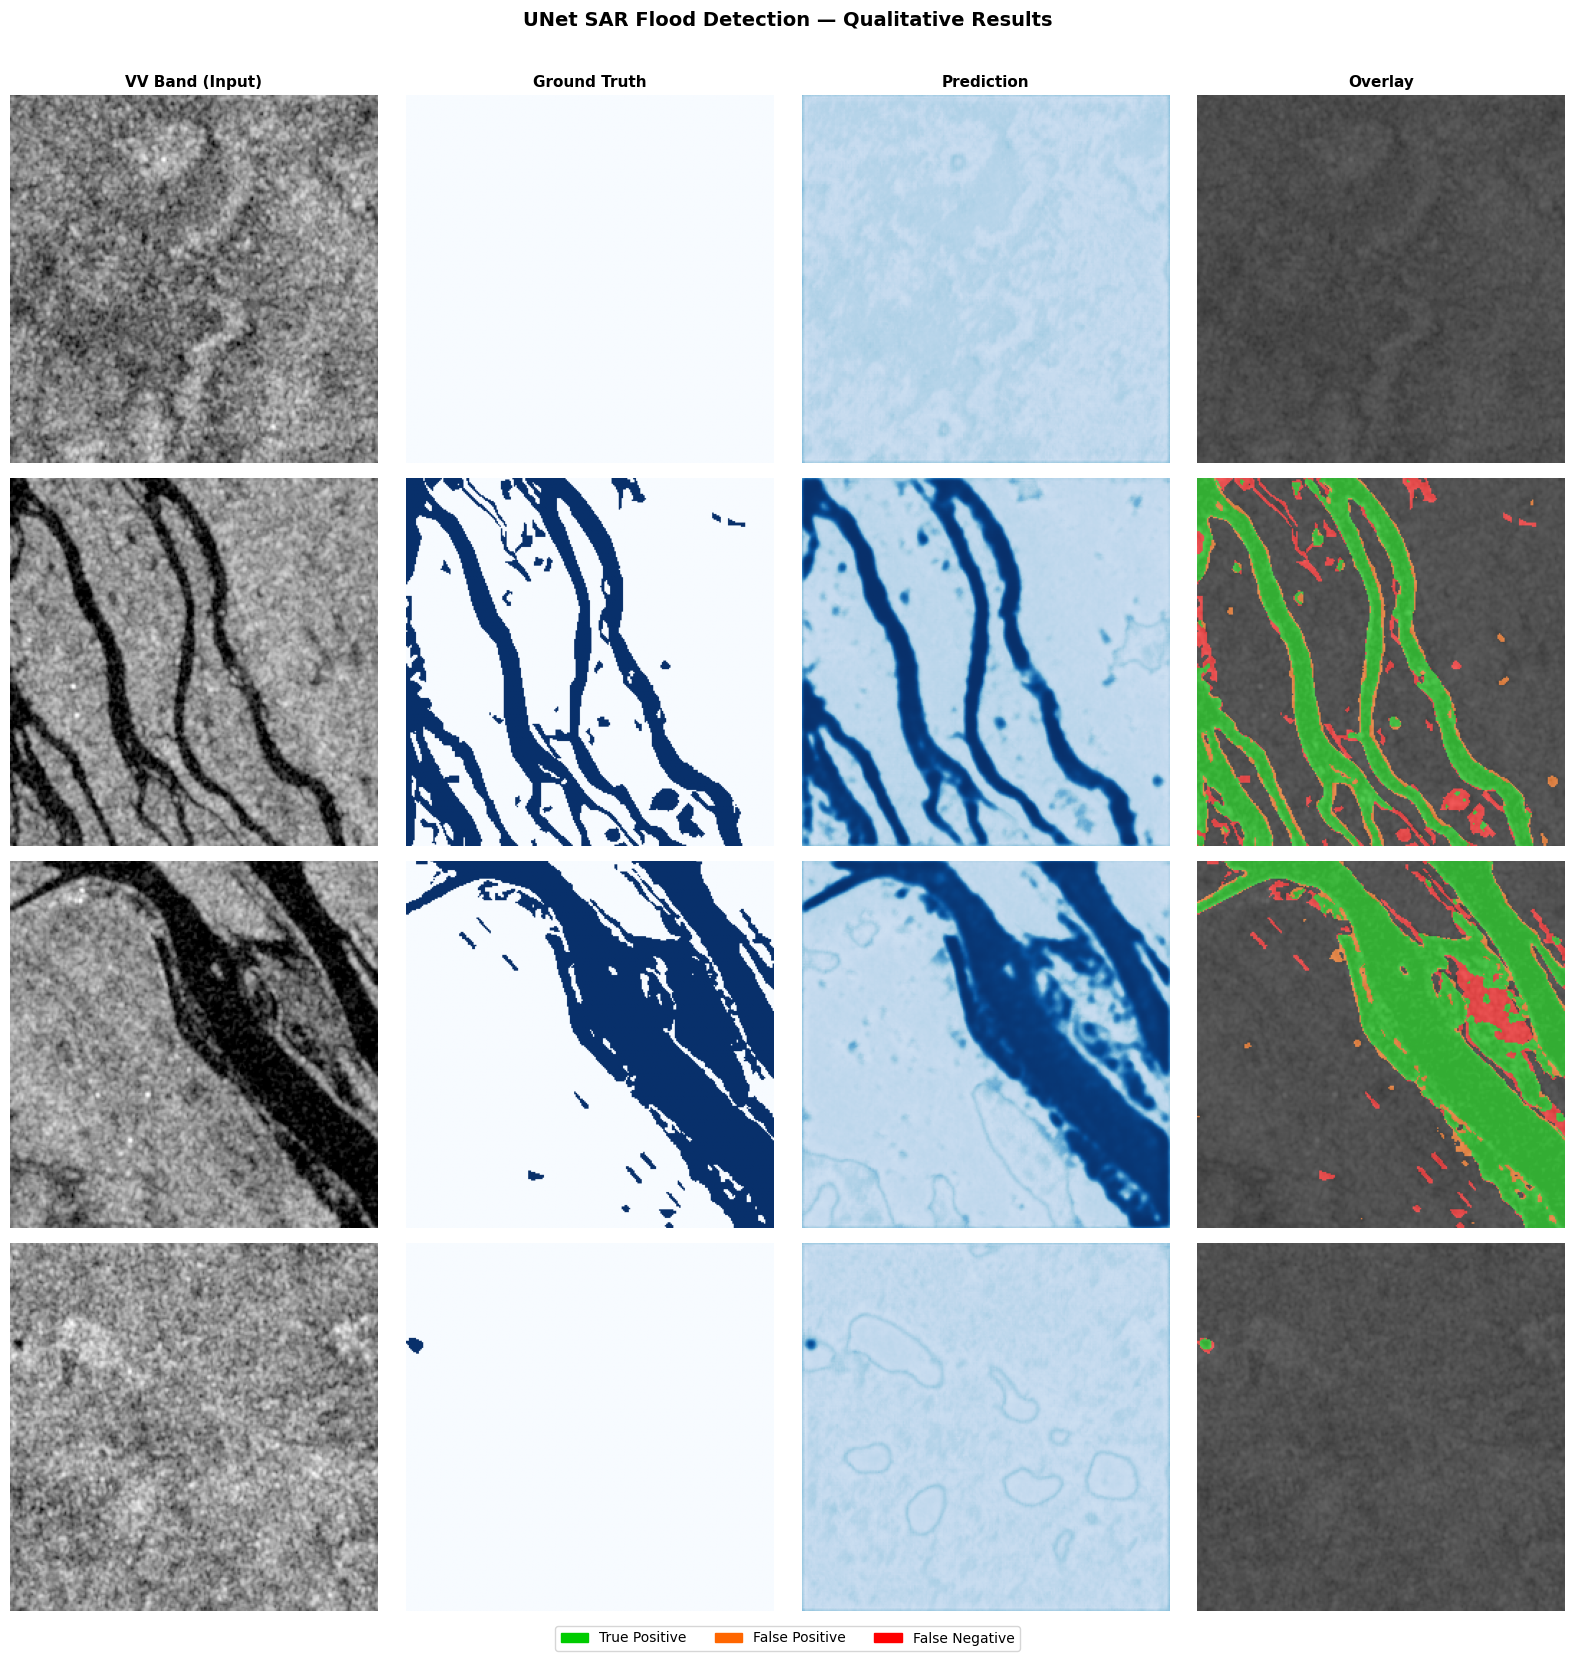

💾 Saved to results/predictions.png


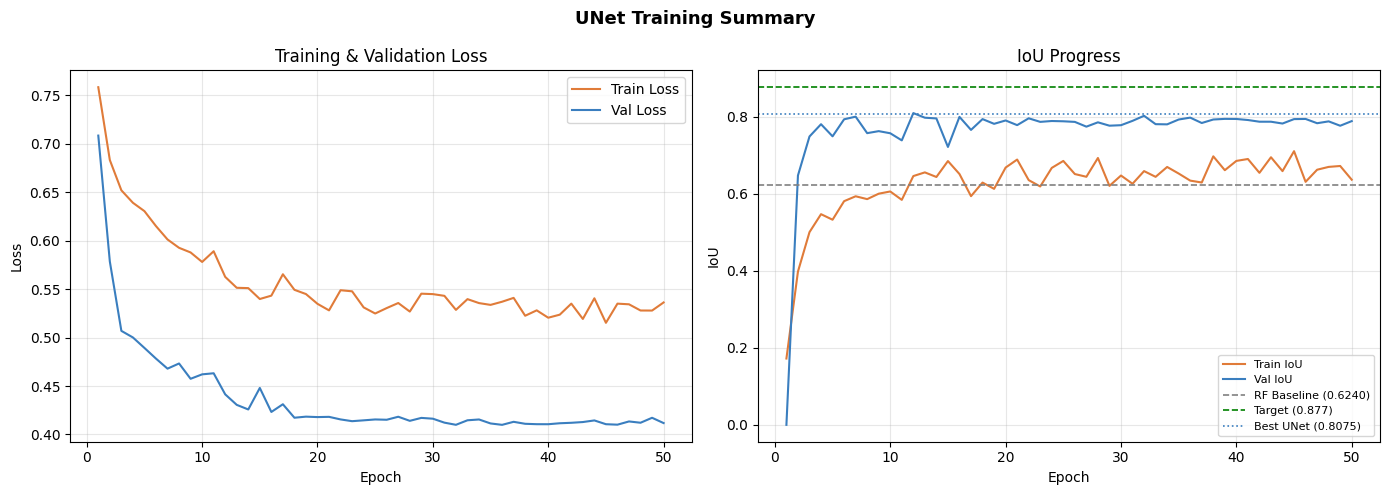

💾 Saved to results/training_curve.png


<Figure size 640x480 with 0 Axes>

In [32]:
%run evaluate.py